# Working Memory Report — HRM on MazeHard

This notebook inspects one artifact-backed HRM MazeHard rollout. The report
follows the model's behavior from final prediction, through recurrent
prediction refinement, into H/L latent-state dynamics and termination
behaviour.

The emphasis is mechanistic rather than distributional: each figure is tied
to a concrete traced rollout and should be read as case-level evidence.


## 1. Report Identity and Execution Status

| Field              | Value                                               |
| ------------------ | --------------------------------------------------- |
| Model family       | HRM v1 (primary), HRM v2 (comparison, if available) |
| Checkpoint         | `checkpoints/hrm-v1/eval-weights-only.pt`           |
| Task               | MazeHard (solution-path prediction)                 |
| Split              | `test`                                              |
| Eval slice         | 1 diagnostic case (`mazehard_n1`)                   |
| ReportRun root     | `artifacts/reports/hrm_v1/mazehard_n1`              |
| Eval artifact root | `artifacts/evaluation/hrm_v1/mazehard_n1`           |
| Created            | TBD                                                 |
| Device / precision | CPU (diagnostic regime)                             |
| Seed               | Not recorded in provenance                          |


## 2. Scientific Question

We inspect whether an HRM-style recurrent controller shows evidence of useful
internal computation on a MazeHard rollout. The report asks three questions:

1. Does the predicted solution improve across recurrent steps?
2. Do the high-level and low-level recurrent states show distinct dynamics?
3. Does the rollout terminate as expected under the current fixed-budget
   evaluation mode?

This mirrors the intended analysis order: behaviour first, recurrent dynamics
second, representational organisation later.


### 2.1 Paper Context: Wang HRM + Whittington Tale

**Wang et al. 2025 (HRM)** answers an implementation question:
How can a model perform latent recurrent reasoning efficiently?
Answer: hierarchical slow/fast recurrent computation with adaptive halting.

**Whittington et al. 2025 (Tale)** answers a representation question:
What should PFC working memory contain?
Answer: structured, controllable activity-based variables (activity slots).

**This notebook** evaluates whether HRM latent recurrent states provide
evidence for PFC-like structured working-memory dynamics during structured
reasoning. Whittington Tale defines the representational target: structured
activity state. MazeHard supports indirect tests through zH/zL persistence,
H/L dissociation, prediction behavior, and adaptive computation.

### Role Summary

| Paper                   | Role in this notebook                                           |
| ----------------------- | --------------------------------------------------------------- |
| Wang et al. 2025        | Primary: model architecture and dynamics                        |
| Whittington et al. 2025 | Primary: representational target for working-memory diagnostics |


### 2.3 Evidence Ladder / Evidence Standard

| Level | Name                             | Description                                               | Target notebook |
| ----- | -------------------------------- | --------------------------------------------------------- | --------------- |
| 0     | Behavioral competence            | HRM solves MazeHard above baseline                        | 02 (this)       |
| 1     | Observable hierarchical dynamics | `z_H` and `z_L` show different temporal profiles          | 02 (this)       |
| 2     | Adaptive control                 | Halting varies with task conditions                       | 02 (this)       |
| 3     | Functional interpretation        | `z_H` appears slow/stable; `z_L` appears fast/transient   | 02 (this)       |
| 4     | Decodable task variables         | Goal, path state, next action decodable from `z_H`/`z_L`  | 02 (future)     |
| 5     | Structured PFC slots             | Item/role/sequence in addressable, controllable subspaces | 03 (future)     |
| 6     | Causal necessity                 | Perturbing slot degrades behavior predictably             | 03 (future)     |

**This notebook targets Levels 0–3.** Level 4 requires decoder infrastructure
not yet built. Levels 5–6 require WM-specific tasks and causal interventions
planned for complementary future infrastructure.


## 3. Task and Benchmark — MazeHard

MazeHard is a structured pathfinding task requiring multi-step reasoning
over a maze-like symbolic environment. The model receives the maze layout
as input and must predict the solution path token-by-token.

### Why MazeHard for PFC/HRM

- Tests hierarchical recurrent computation (Wang HRM).
- Requires multi-step state maintenance and local action selection.
- Provides `z_H`, `z_L`, and halting traces for dynamics analysis.

### Limitations for isolated slot-addressability tests

MazeHard supports indirect working-memory evidence (state persistence,
H/L dissociation, adaptive control) but does not isolate slot-addressable
memory from reasoning. Stronger tests require:

- Cue-dependent recall (isolates retrieval from encoding)
- Item-position binding (tests structured representational slots)
- Counterfactual cue interventions (tests controllability)
- Delay-period distractors (tests active maintenance)

The report uses one MazeHard evaluation case. The task is to predict a
solution-path overlay for the maze input.

### Case metadata

| Field             | Value                                                     |
| ----------------- | --------------------------------------------------------- |
| Regime            | `mazehard_n1`                                             |
| Case ID           | `mazehard-test-0000`                                      |
| Target-path cells | (populated from trace)                                    |
| Rollout steps     | 16                                                        |
| Vocabulary        | 6 tokens (obstacle, empty,\n start, target, path, unused) |

### Benchmark Parameters| Provider | `MazeHardReplayProvider` |

| Cases in this slice | 1 (diagnostic, not full benchmark) |

| Parameter | Value || Split | `test` |

| ------------------- | ---------------------------------- || Task family | `mazehard` |


## 4. Model Internals Inspected

The HRM architecture separates high-level context/plan states (`z_H`) from
low-level computation states (`z_L`) via a hierarchical recurrent design.
This report inspects the following trace variables captured during offline
evaluation.

| System | Scientific role | Trace | Report-facing name | Evidence section |
| ------ | --------------- | ----- | ------------------ | ---------------- |

> **Note:** HRM traces (... todo) ...


In [1]:
from ehc_sn.reporting import open_report
from IPython.display import Image, Markdown, display

# Report paths
HRM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/hrm_v1/mazehard_n1"
HRM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/hrm_v2/mazehard_n1"

# Load reports
hrm_v1_report = open_report(HRM_V1_REPORT_PATH)
hrm_v2_report = open_report(HRM_V2_REPORT_PATH)

# Display report summaries for hrm_v1
print("HRM v1 report summary:")
print(f"\t report:   {hrm_v1_report.root}")
print(f"\t metrics:  {hrm_v1_report.summary()['metric_count']}")
print(f"\t metrics:  {hrm_v2_report.summary()['metric_count']}")

# Display report summaries for hrm_v1
print("HRM v2 report summary:")
print(f"\t report:   {hrm_v2_report.root}")
print(f"\t figures:  {hrm_v1_report.summary()['figure_count']}")
print(f"\t figures:  {hrm_v2_report.summary()['figure_count']}")

HRM v1 report summary:
	 report:   /home/borja/ehc-sn/artifacts/reports/hrm_v1/mazehard_n1
	 metrics:  7
	 metrics:  7
HRM v2 report summary:
	 report:   /home/borja/ehc-sn/artifacts/reports/hrm_v2/mazehard_n1
	 figures:  10
	 figures:  10


## 5. Training Dynamics and Checkpoint Selection

| Field                     | Status                                                                                                                                                                                                                                                      |
| ------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| ReportRun-backed          | ❌ Pending                                                                                                                                                                                                                                                  |
| Source needed             | Training logs / TensorBoard / Lightning metrics                                                                                                                                                                                                             |
| Current blocker           | Training logs are not yet ingested into the ReportRun artifact                                                                                                                                                                                              |
| Interpretation constraint | Behavioral and representational results below describe the selected checkpoint only. They do **not** establish convergence, and the reader cannot distinguish learned structure from overfit memorisation on this small eval slice without training curves. |

**Required diagnostics (future):**

- `train/loss`, `val/loss`
- Prediction accuracy over training steps
- Loss components (token prediction, halting, auxiliary)
- Learning rate schedule
- Gradient norm history

> Until training curves are available, the checkpoint selection is
> unvalidated. Results in the sections below should be read as describing a
> single checkpoint, not a converged model.


## 6. Behavioral Performance

The scalar metrics below summarise final prediction quality for the traced
rollout. They should be read together with the prediction-over-time figures
in §7.

**Chance baseline:** Depends on vocabulary size and maze difficulty. For a
token-level uniform baseline the expected accuracy is low.

> High token accuracy can coexist with sequence-level failure because the
> overlay is background-dominated. The path-specific figures in §7 are
> therefore necessary for interpretation.


In [2]:
# Display metrics from both ReportRuns
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    metrics = report.metrics()
    print(f"\n{label}:")
    for m in metrics:
        hb = " (higher is better)" if m.higher_is_better else ""
        print(f"  {m.metric:<30s} {m.value:<8} {m.unit or '—':<10s} {hb}")

print()
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    s = report.summary()
    print(
        f"{label}: {s['model_family']}, {s['metric_count']} metrics, "
        f"{s['figure_count']} figures"
    )


HRM v1:
  token_accuracy                 0.9622222222222222 ratio       (higher is better)
  sequence_accuracy              0.9622222185134888 ratio       (higher is better)
  sequence_exact                 0.0      ratio       (higher is better)
  n_token_correct                866      count       (higher is better)
  n_token_total                  900      count      
  n_sequence_completed           1        count      
  n_sequence_eligible            16       count      

HRM v2:
  token_accuracy                 0.9622222222222222 ratio       (higher is better)
  sequence_accuracy              0.9622222185134888 ratio       (higher is better)
  sequence_exact                 0.0      ratio       (higher is better)
  n_token_correct                866      count       (higher is better)
  n_token_total                  900      count      
  n_sequence_completed           1        count      
  n_sequence_eligible            16       count      

HRM v1: hrm-v1, 7 metrics, 10 fig

## 7. Prediction Examples and Error Taxonomy

This section shows behavioral prediction overlays — per-step comparisons
between ground-truth solution paths and model-predicted paths.

### Mazehard Task Overview (paradigm context)

...


In [3]:
# Mazehard Task Overview (paradigm context; same dataset for both models)
overview_entry = hrm_v1_report.figure_entry(
    "mazehard_task_layout", preferred_format="png"
)
if overview_entry:
    abs_path = hrm_v1_report.root / overview_entry.path
    print(f"Mazehard Task Overview (case={overview_entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("mazehard_task_layout not available.")

mazehard_task_layout not available.


### Mazehard Prediction Overlays

....


HRM v1 — mazehard_prediction_evolution (case=mazehard_n1)


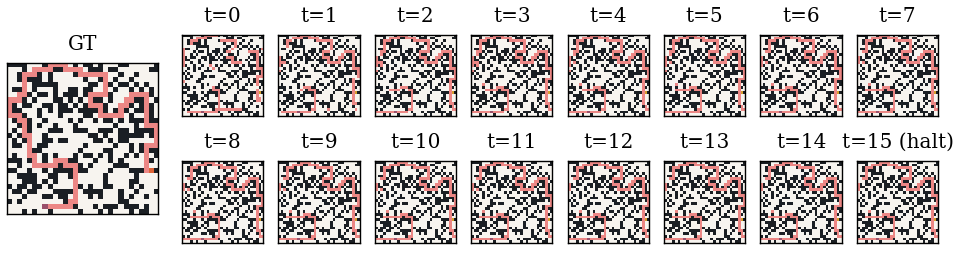


HRM v2 — mazehard_prediction_evolution (case=mazehard_n1)


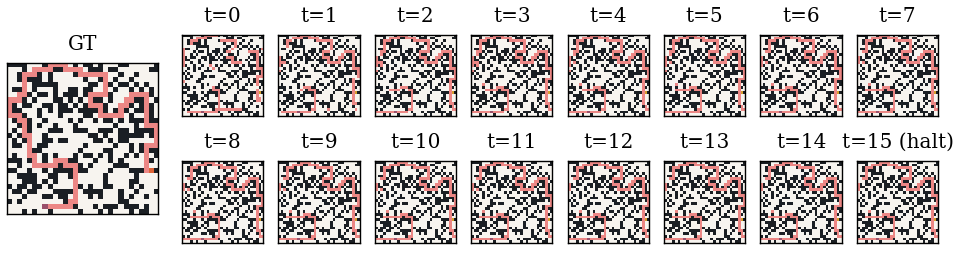

In [8]:
# --- PFC Latent ....
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("mazehard_prediction_evolution", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mazehard_prediction_evolution not available.")
    print()

## 8. PFC Latent State Dynamics

todo ...



HRM v1 — pfc_latent_dynamics (case=mazehard_n1)


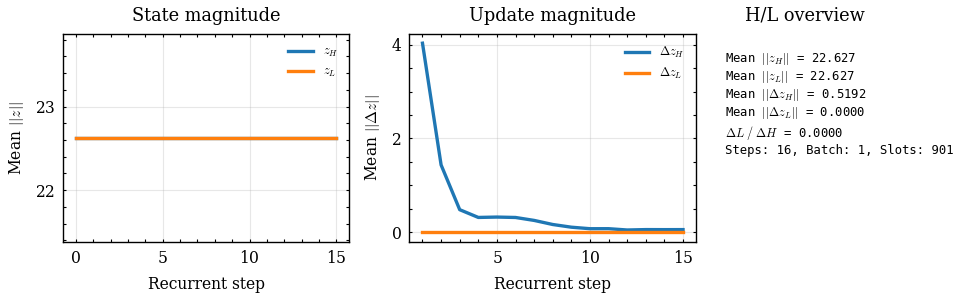


HRM v2 — pfc_latent_dynamics (case=mazehard_n1)


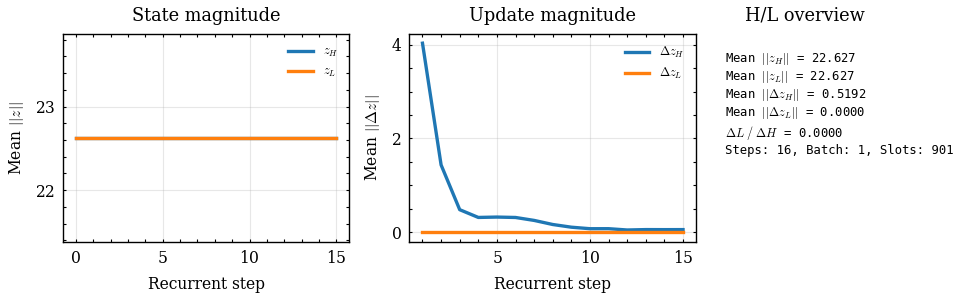

In [5]:
# --- PFC Latent ....
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("pfc_latent_dynamics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: pfc_latent_dynamics not available.")
    print()

todo: we need to merge this 2 into one section as we have the figure for both?

## 9. L-State Diagnostics — Fast Computation / Local Update State
## 9. H-State Diagnostics — Slow Working-Memory / Plan State

This section focuses on detailed H/L recurrent dynamics. The
`h_l_residuals_over_steps` figure compares forward residuals, consecutive-step
cosine similarity, and the L/H residual ratio across recurrent rollout steps.

> **Caveat:** The current evaluation is fixed-budget. The figure describes
> continuous recurrent dynamics, not learned ACT cycles or reset events.



This section evaluates whether the HRM high-level state (`z_H`) behaves like
a slow, persistent PFC working-memory state. In the Wang HRM framing, `z_H`
should change more slowly than `z_L` and preserve task-level context across
recurrent computation. In the Whittington framing, this is the candidate
substrate in which structured working-memory variables could be maintained.

**Expected signature:**

- `z_H` has lower temporal delta than `z_L`.
- `z_H` remains stable across local recurrent updates.
- `z_H` dynamics are compatible with persistent task context or plan state.

**What this shows:**

- Whether the high-level recurrent state has slow temporal dynamics.
- Whether the checkpoint exposes measurable H-state trajectories.

**What this does not show:**

- Whether `z_H` semantically encodes goal, plan, item, or slot variables.
- Whether `z_H` is causally necessary for behavior.
- Whether `z_H` contains addressable activity slots.

> **Caveat:** Norm and delta dynamics show temporal structure, not semantic
> content. They cannot prove planning or working memory by themselves.
> This is Level 1–2 evidence under §2.3.


HRM v1 — h_l_residuals_over_steps (case=mazehard_n1)


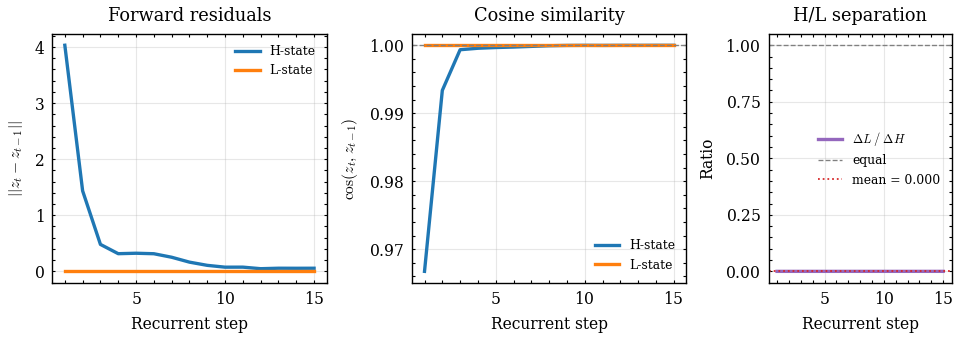


HRM v2 — h_l_residuals_over_steps (case=mazehard_n1)


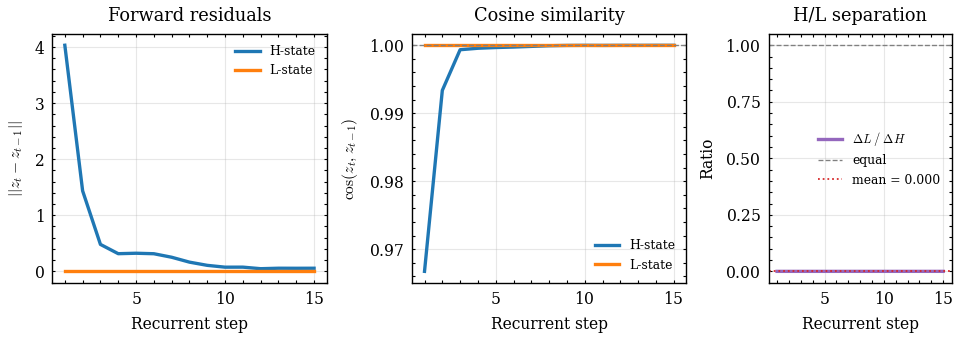

In [6]:
# --- L-State ....
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("h_l_residuals_over_steps", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: h_l_residuals_over_steps not available.")
    print()

## 10. Halting and Adaptive Computation

This section verifies the rollout termination signal. In the current
fixed-budget evaluation mode, termination occurs at the configured maximum
recurrent step.

The halt trace is interpreted here as a termination diagnostic. Learned early
stopping requires a separate evaluation mode with learned halting enabled.


HRM v1 — halting_timeline (case=mazehard_n1)


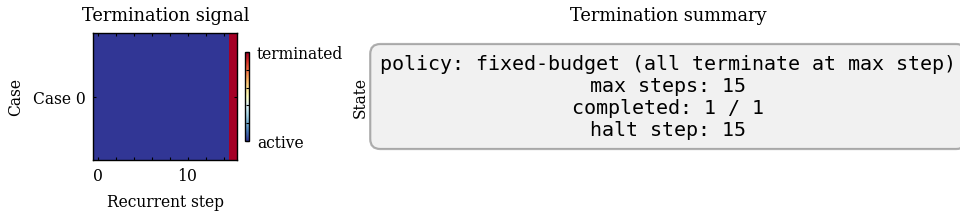


HRM v2 — halting_timeline (case=mazehard_n1)


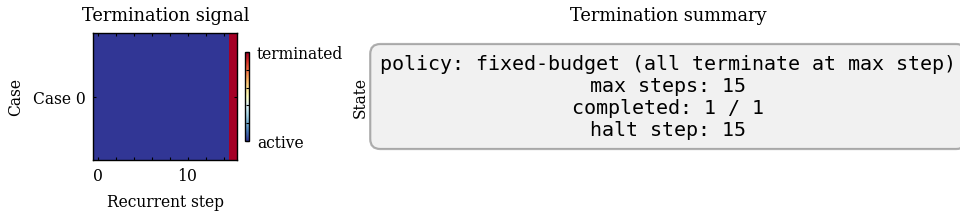

In [7]:
# --- Halting
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("halting_timeline", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: halting_timeline not available.")
    print()

todo: check where this figure and its explanation goes then delete this section
## And where should this figure go???

figure: prediction_accuracy_over_steps


HRM v1 — prediction_accuracy_over_steps (case=mazehard_n1)


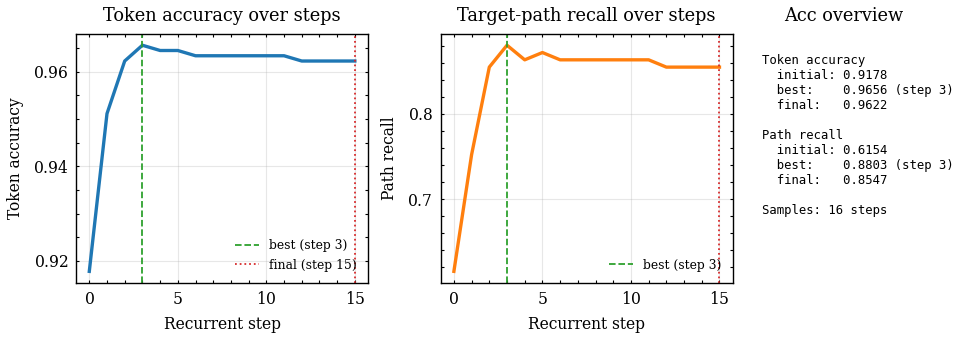


HRM v2 — prediction_accuracy_over_steps (case=mazehard_n1)


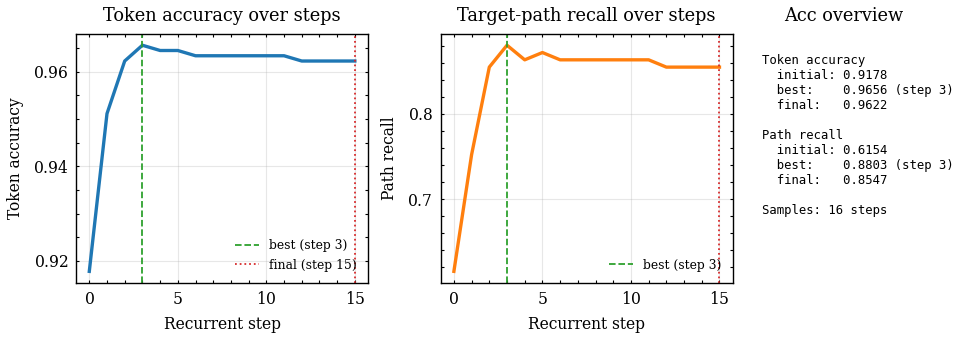

In [ ]:
# --- Halting
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry(
        "prediction_accuracy_over_steps", preferred_format="png"
    )
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: prediction_accuracy_over_steps not available.")
    print()

## 11. Evidence Gaps and Next Steps

| Missing claim                      | Why it matters                                        | Current blocker                     | Next artifact needed                   |
| ---------------------------------- | ----------------------------------------------------- | ----------------------------------- | -------------------------------------- |
| `z_H` encodes plan-level variables | Needed for PFC controller interpretation              | No decoder infrastructure           | `diagnostics/wm_decoding.py`           |
| `z_L` encodes local execution      | Needed for H/L functional dissociation                | No decoder infrastructure           | `diagnostics/wm_decoding.py`           |
| HRM-specific dynamics              | Need to rule out generic recurrent dynamics           | No flat RNN/GRU baseline eval       | Flat RNN trained checkpoint + eval run |
| Whittington-style activity slots   | Core PFC representation claim from Tale 2025          | No cue-recall eval task in pipeline | Cue-recall task provider + eval config |
| Cue-controllable slot access       | Needed for \"controllable\" part of Tale claim        | No counterfactual cue test infra    | Complementary future infra             |
| Causal necessity of `z_H`/`z_L`    | Needed for mechanistic (not just correlational) claim | No perturbation/ablation infra      | Ablation config + eval run             |

### Priority Order for Next Implementation

1. **Generate HRM MazeHard eval artifacts** — unblocks all display sections.
2. **Build H/L decoder infrastructure** — enables Level 4 evidence.
3. **Train and evaluate flat RNN/GRU baseline** — enables specificity claim.
4. **Implement cue-recall eval pipeline** — enables complementary future WM tasks.
5. **Build perturbation/ablation infrastructure** — enables Level 6 evidence.


## 12. Evidence Summary

| Claim                                        | Variable / Pathway                      | Current status                                                                                      | Verdict                                                                                             |
| -------------------------------------------- | --------------------------------------- | --------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| HRM MazeHard behavior is measurable          | Output predictions                      | No HRM ReportRun present                                                                            | ⚠️ Not yet evaluated in current artifact state                                                      |
| Solution prediction overlays are inspectable | `pred/solution_overlay`                 | No HRM ReportRun present                                                                            | ⚠️ Not yet evaluated in current artifact state                                                      |
| `z_H` and `z_L` traces are collectible       | `pfc/z_H`, `pfc/z_L`                    | No HRM ReportRun present                                                                            | ⚠️ Not yet evaluated in current artifact state                                                      |
| H/L temporal dynamics are measurable         | `pfc/z_H`, `pfc/z_L`, `h_l_delta_ratio` | No HRM ReportRun present                                                                            | ⚠️ Not yet evaluated in current artifact state                                                      |
| Adaptive halting is measurable               | `act/halted`                            | No HRM ReportRun present                                                                            | ⚠️ Not yet evaluated in current artifact state                                                      |
| Wang-style hierarchical timescale separation | `pfc/z_H`, `pfc/z_L`, `h_l_delta_ratio` | No HRM ReportRun present                                                                            | ⚠️ Not yet evaluated in current artifact state                                                      |
| PFC-like reasoning-engine interpretation     | H/L dynamics + halting                  | compatible, not proven                                                                              | ⚠️ Suggestive / conditional — compatible but not causally tested                                    |
| `z_H` encodes plan-level variables           | `pfc/z_H`                               | No decoder infrastructure                                                                           | ❌ Not yet evaluated                                                                                |
| Whittington-style activity slots             | zH/zL dynamics + halting                | Working-memory signatures testable via MazeHard; full slot-addressability requires cue-recall tasks | ⚠️ Partial — working-memory dynamics testable; isolated slot-control requires future infrastructure |
| Causal role of `z_H`/`z_L` is established    | Perturbation / ablation                 | No perturbation infra                                                                               | ❌ Not yet evaluated                                                                                |

**Bottom line:** This notebook currently defines the evidence contract for evaluating HRM as a PFC-like hierarchical working-memory and reasoning substrate. Whittington Tale defines the representational target: structured activity state. Existing code supports zH/zL dynamics, halting, and MazeHard solution overlays, but no HRM ReportRun is present yet; therefore behavioral and latent-dynamics claims remain unevaluated until the MazeHard artifacts are generated.

## 13. Reproducibility

### Artifact Paths

| Artifact                | Path                                       |
| ----------------------- | ------------------------------------------ |
| HRM v1 ReportRun        | `artifacts/reports/hrm_v1/mazehard_n1`     |
| HRM v1 eval artifacts   | `artifacts/evaluation/hrm_v1/mazehard_n1`  |
| HRM v1 checkpoint       | `checkpoints/hrm-v1/eval-weights-only.pt`  |
| HRM v1 model config     | `config/models/hrm-v1-base.toml`           |
| HRM v1 report spec      | `config/reporting/hrm_v1_mazehard_n1.toml` |
| MazeHard benchmark spec | `spec/spec-benchmark-suite.md`             |

### Commands to Reproduce

```bash
# Generate evaluation artifacts with all diagnostic traces (n=1)
python scripts/evaluation/run_eval.py \
    --model-family hrm-v1 \
    --checkpoint checkpoints/hrm-v1/eval-weights-only.pt \
    --config config/evaluation/hrm-v1-mazehard.toml \
    --task mazehard \
    --provider-ref ehc_sn.tasks.mazehard.providers.MazeHardReplayProvider \
    --regime-id mazehard_n1 --regime-kind diagnostic \
    --trace-keys pfc/z_H,pfc/z_L,act/halted,pred/solution_overlay \
    --output artifacts/evaluation/hrm_v1/mazehard_n1 \
    --device cpu

# Generate ReportRun from eval artifacts
    --config config/reporting/hrm_v1_mazehard_n1.toml
```

### Known Reproducibility Gaps

| Gap                            | Impact                               |
| ------------------------------ | ------------------------------------ |
| Git commit SHA not recorded    | Cannot pin the exact code version    |
| Checkpoint SHA256 not recorded | Cannot verify checkpoint integrity   |
| Random seed not recorded       | Cannot reproduce stochastic elements |

| HRM v2 / EHC v1 checkpoints | Not yet evaluated; hierarchical-reasoning comparison incomplete |
